# Project 4 - Group 1

## Importing Data

In [1]:
#Importing Packages
#%pip install geopandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd

In [11]:
#Load in Dictionary
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

#Load in Census Tracts
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")

#Load in Arkansas data
ar_tracts = all_tracts[all_tracts["STATE"] == "Arkansas"]
ar_tracts.to_csv("ar_tracts.csv")
ar_nri = pd.read_csv("NRI_Table_CensusTracts.csv")
ar_svi = pd.read_csv("Arkansas.csv")

#Load in Misouri data
ms_tracts = all_tracts[all_tracts["STATE"] == "Missouri"]
ms_tracts.to_csv("ms_tracts.csv")
ms_nri = pd.read_csv("NRI_Table_CensusTracts.csv")
ms_svi = pd.read_csv("Missouri.csv")

## Handling Missing Values

### Arkansas

In [13]:
## Identify NAs
ar_nri = pd.read_csv("ar_tracts.csv", low_memory = True)
ar_nri = pd.DataFrame(ar_nri)
ar_nri.isna()

,Unnamed: 0,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
819,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
820,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
821,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
## Imputate the median for NAs
# This replaces empty sets with the median value, which will be most applicable for this scenario and allows us to not have gaps in analysis
ar_nri_filled_median = ar_nri.fillna(ar_nri.median(numeric_only = True))

### Missouri

In [17]:
## Identify NAs
ms_sri = pd.read_csv("ms_tracts.csv", low_memory = True)
ms_nri = pd.DataFrame(ms_nri)
ms_nri.isna()

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85149,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
85150,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
85151,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
85152,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
## Imputate the median for NAs
# This replaces empty sets with the median value, which will be most applicable for this scenario and allows us to not have gaps in analysis
ms_nri_filled_median = ms_nri.fillna(ms_nri.median(numeric_only = True))

## Merging Data

In [21]:
# Merging NRI and SVI data for Arkansas
ar_nri['STCNTY'] = ar_nri['STCOFIPS']
ar_nri.columns
complete_data_ar = pd.merge(ar_nri, ar_svi, on = 'STCNTY')
complete_data_ar.columns

Index(['Unnamed: 0', 'OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS',
       'COUNTY_x', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=626)

In [23]:
# Merging NRI and SVI data for Missouri
ms_nri['STCNTY'] = ms_nri['STCOFIPS']
ms_nri.columns
complete_data_ms = pd.merge(ms_nri, ms_svi, on = 'STCNTY')
complete_data_ms.columns

Index(['OID_', 'NRI_ID', 'STATE_x', 'STATEABBRV', 'STATEFIPS', 'COUNTY_x',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

## Creating New Columns

In [25]:
### Creating Columns for the NRI Definition of Risk (Expected Annual Building Loss Rate * Frequency of Tornados)
## Arkansas
complete_data_ar['NRI_risk_EABL_Tornado_AR'] = complete_data_ar['TRND_ALRB']*complete_data_ar['TRND_AFREQ']

## Missouri
complete_data_ms['NRI_risk_EABL_Torando_MS'] = complete_data_ms['TRND_ALRB']*complete_data_ms['TRND_AFREQ']

In [49]:
## ### Creating Columns for the Group Definition of Risk
## Arkansas
# Impact on building loss (probability * building loss) (NOTE: Probability = Frequency * # of events)
complete_data_ar['G1_risk_Tornado_AR'] = complete_data_ar['TRND_AFREQ']*complete_data_ar['TRND_EVNTS']*complete_data_ar['TRND_ALRB']

## Missouri
# Impact on building loss (probability * building loss) (NOTE: Probability = Frequency * # of events)
complete_data_ms['G1_risk_Tornado_MS'] = complete_data_ms['TRND_AFREQ']*complete_data_ms['TRND_EVNTS']*complete_data_ms['TRND_ALRB']

## Creating Bar Plots for both Risk Definitions for Each State

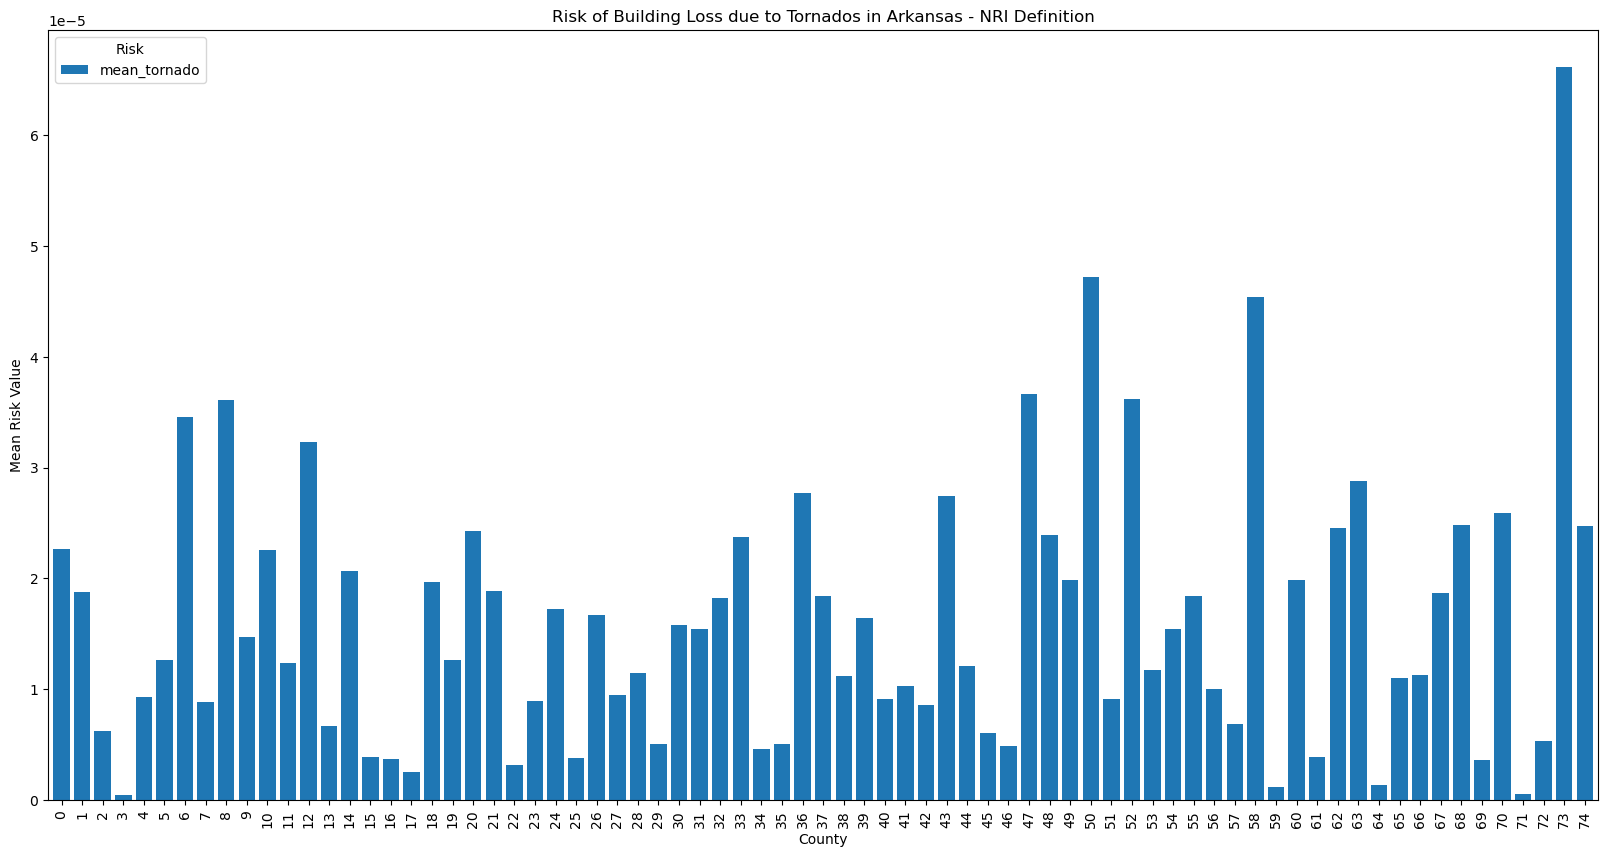

In [31]:
### NRI Definition - Arkansas
## Grouping data by county and aggregating it into the mean values for the NRI Risk definition
grouped_data_ar_nri= complete_data_ar.groupby('COUNTY_x', as_index=False).agg(
    mean_tornado=('NRI_risk_EABL_Tornado_AR', 'mean'))


### Bar plot for grouped/aggregated data
grouped_data_ar_nri.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Risk of Building Loss due to Tornados in Arkansas - NRI Definition')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk") 
plt.show()

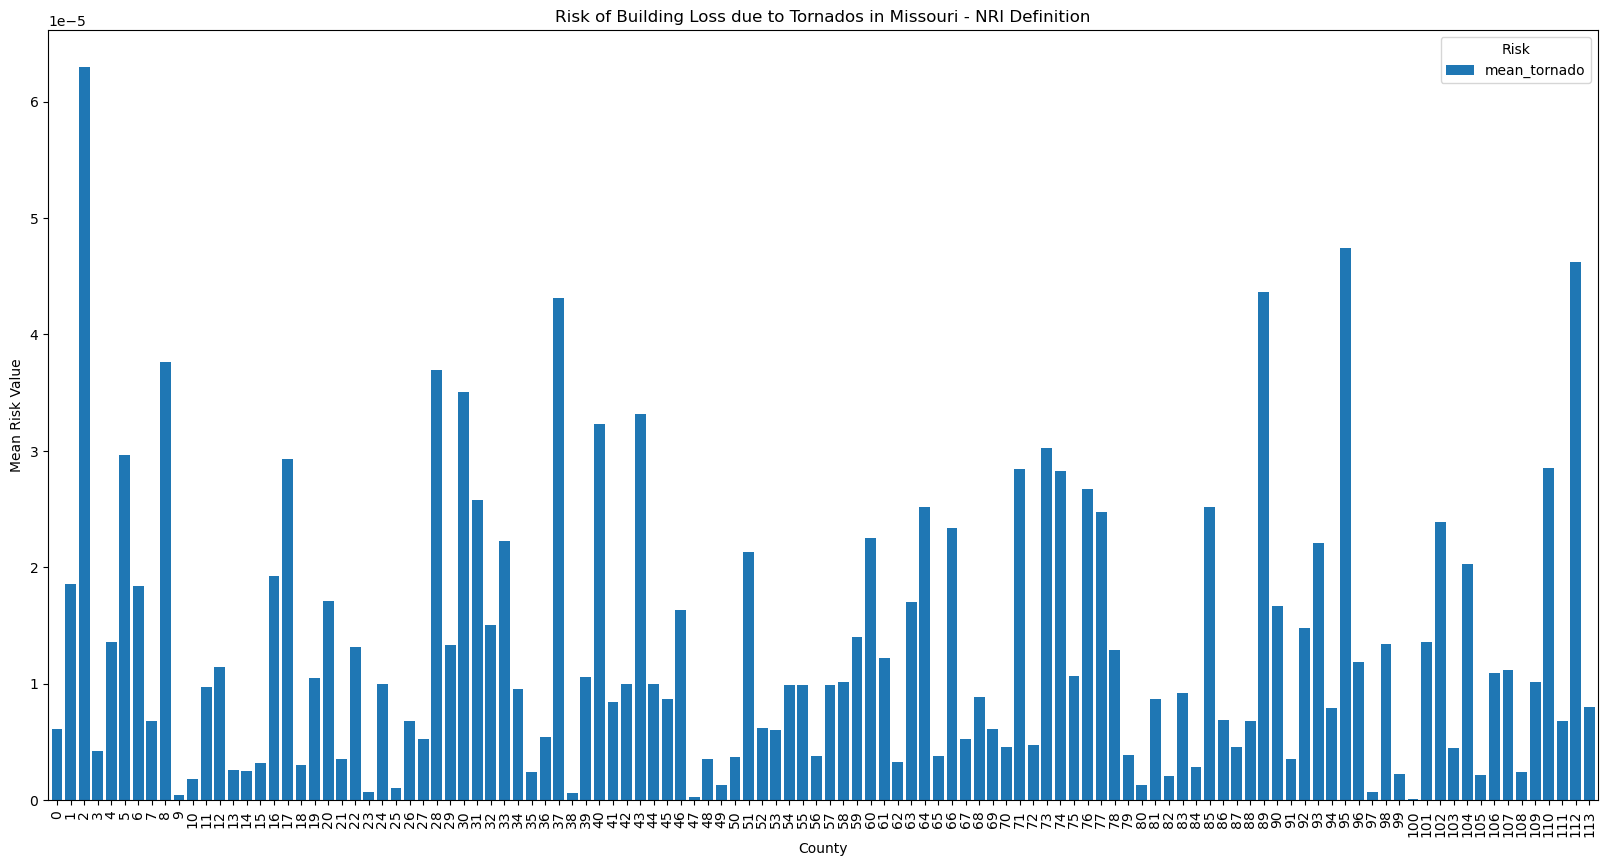

In [32]:
### NRI Definition - Missouri
## Grouping data by county and aggregating it into the mean values for the NRI Risk definition
grouped_data_ms_nri= complete_data_ms.groupby('COUNTY_x', as_index=False).agg(
    mean_tornado=('NRI_risk_EABL_Torando_MS', 'mean'))


### Bar plot for grouped/aggregated data
grouped_data_ms_nri.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Risk of Building Loss due to Tornados in Missouri - NRI Definition')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk") 
plt.show()

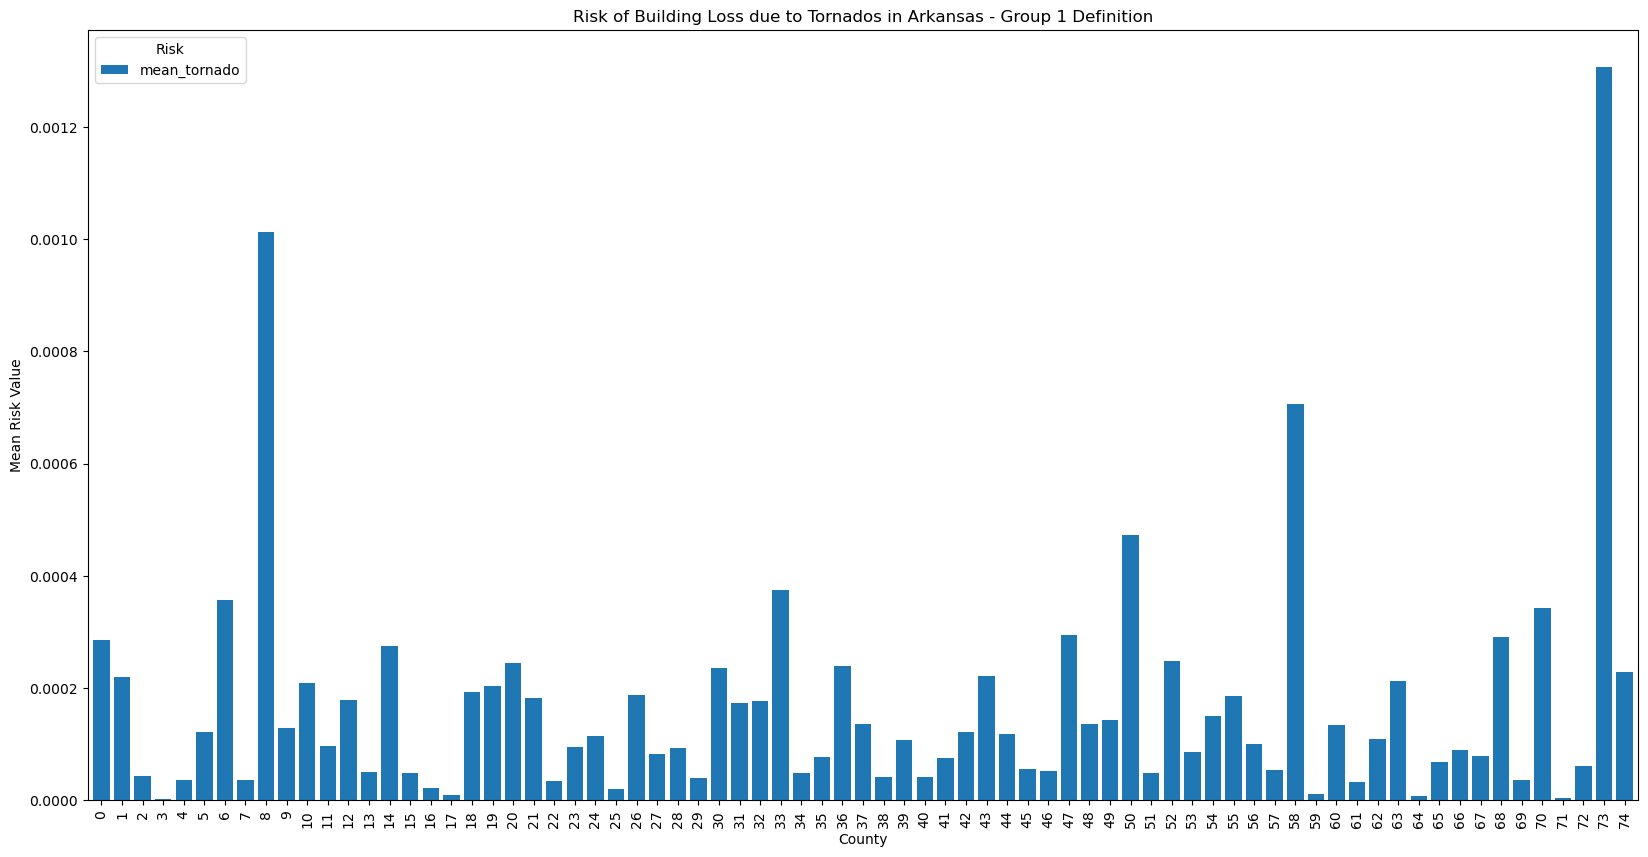

In [34]:
### Group 1 Definition - Arkansas
## Grouping data by county and aggregating it into the mean values for the Group Risk definition
grouped_data_ar_G1 = complete_data_ar.groupby('COUNTY_x', as_index=False).agg(
    mean_tornado=('G1_risk_Tornado_AR', 'mean'))


### Bar plot for grouped/aggregated data
grouped_data_ar_G1.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Risk of Building Loss due to Tornados in Arkansas - Group 1 Definition')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk") 
plt.show()

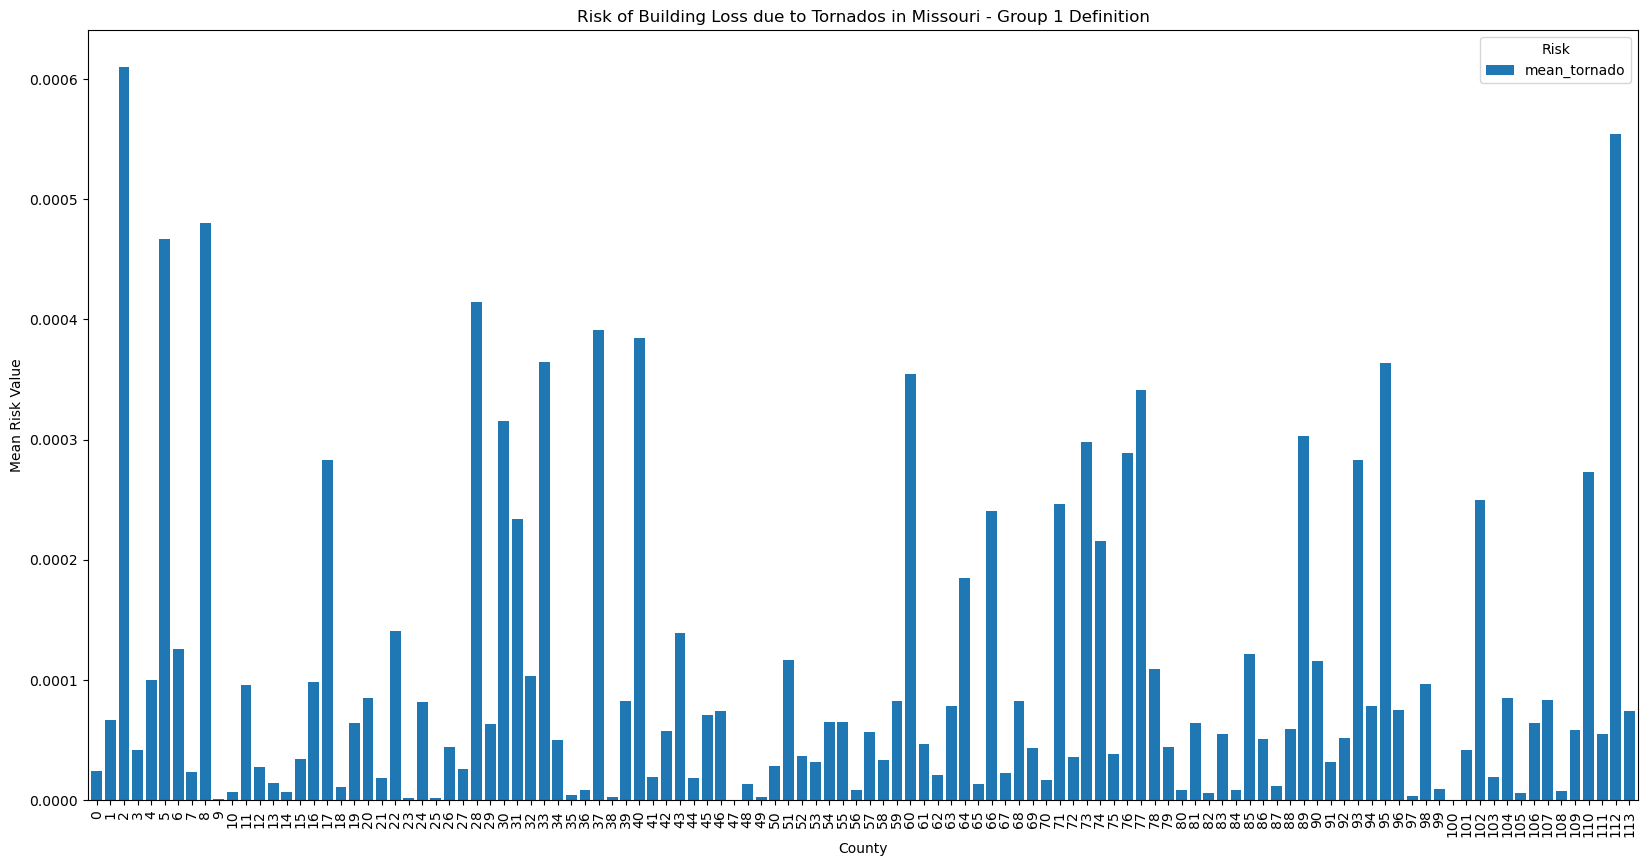

In [36]:
### Group 1 Definition - Missouri
## Grouping data by county and aggregating it into the mean values for the Group Risk definition
grouped_data_ms_G1 = complete_data_ms.groupby('COUNTY_x', as_index=False).agg(
    mean_tornado=('G1_risk_Tornado_MS', 'mean'))


### Bar plot for grouped/aggregated data
grouped_data_ms_G1.plot(kind='bar', figsize=(20, 10), width=0.8)

# Customizing the plot
plt.xlabel('County')
plt.ylabel('Mean Risk Value')
plt.title('Risk of Building Loss due to Tornados in Missouri - Group 1 Definition')
plt.xticks(rotation=90)

# Show the plot
plt.legend(title="Risk") 
plt.show()

## Generating Maps to Communicate Risk Information

### Cleaning Data for Mapping

In [55]:
## Read the Census Tracts data
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')


# Check the projection and set it
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True)

# Transform to a new CRS 
tracts_clean = tracts_clean.to_crs(epsg = 4326)

# Replace -9999 nulls with NaN
tracts_clean = tracts_clean.replace(-9999, np.nan)

# Tell GeoPandas the data is actually Web Mercator 
tracts_clean.crs = "EPSG:3857"

# Convert it to degrees to match xlim/ylim
tracts_clean = tracts_clean.to_crs(epsg = 4326)

# Standard projection for US National maps
tracts_clean = tracts_clean.to_crs("ESRI:102003")
tracts_clean.head()


,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."


## Arkansas Maps 

In [46]:
# Filter for Arkansas in SHP file
ar = "Arkansas"
state_map_ar = tracts_clean[tracts_clean["STATE"] == ar]

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
3377,T05001480100,Arkansas,AR,05,Arkansas,County,001,05001,480100,05001480100,...,4.017037e-09,0.000033,91.368579,3389.190563,66.527137,Relatively Moderate,March 2023,262084.753571,1.040584e+09,"POLYGON ((431327.01 -322102.732, 431332.464 -3..."
3378,T05001480200,Arkansas,AR,05,Arkansas,County,001,05001,480200,05001480200,...,4.017037e-09,0.000033,91.292247,4291.459477,71.254103,Relatively Moderate,March 2023,191918.566988,1.105143e+09,"POLYGON ((417321.093 -318663.201, 417326.125 -..."
3379,T05001480300,Arkansas,AR,05,Arkansas,County,001,05001,480300,05001480300,...,4.017037e-09,0.000033,85.238509,3862.863488,69.187319,Relatively Moderate,March 2023,38964.986284,6.710299e+07,"POLYGON ((409009.023 -330277.934, 408774.367 -..."
3380,T05001480400,Arkansas,AR,05,Arkansas,County,001,05001,480400,05001480400,...,4.017037e-09,0.000033,86.255490,5385.791181,75.455454,Relatively Moderate,March 2023,46031.317148,9.145503e+07,"POLYGON ((412038.431 -318781.469, 411920.481 -..."
3381,T05001480500,Arkansas,AR,05,Arkansas,County,001,05001,480500,05001480500,...,4.017037e-09,0.000033,85.522700,7338.386772,80.957761,Relatively Moderate,March 2023,26361.452608,2.067604e+07,"POLYGON ((409009.023 -330277.934, 409005.102 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,T05149952302,Arkansas,AR,05,Yell,County,149,05149,952302,05149952302,...,7.322360e-08,0.000040,95.677244,25812.848538,94.923417,Relatively High,March 2023,46468.741641,4.481704e+07,"POLYGON ((249385.56 -245711.167, 249499.881 -2..."
4196,T05149952401,Arkansas,AR,05,Yell,County,149,05149,952401,05149952401,...,7.322360e-08,0.000040,96.602626,39436.013387,97.004471,Relatively High,March 2023,127521.458688,3.287748e+08,"POLYGON ((235535.69 -270125.589, 235537.647 -2..."
4197,T05149952402,Arkansas,AR,05,Yell,County,149,05149,952402,05149952402,...,7.322360e-08,0.000040,95.658454,52344.158805,97.977215,Very High,March 2023,209646.034158,6.931131e+08,"POLYGON ((253570.876 -252240.267, 253573.265 -..."
4198,T05149952500,Arkansas,AR,05,Yell,County,149,05149,952500,05149952500,...,7.322360e-08,0.000040,96.539211,69940.363000,98.693098,Very High,March 2023,247825.133267,7.243158e+08,"POLYGON ((235535.69 -270125.589, 235546.633 -2..."


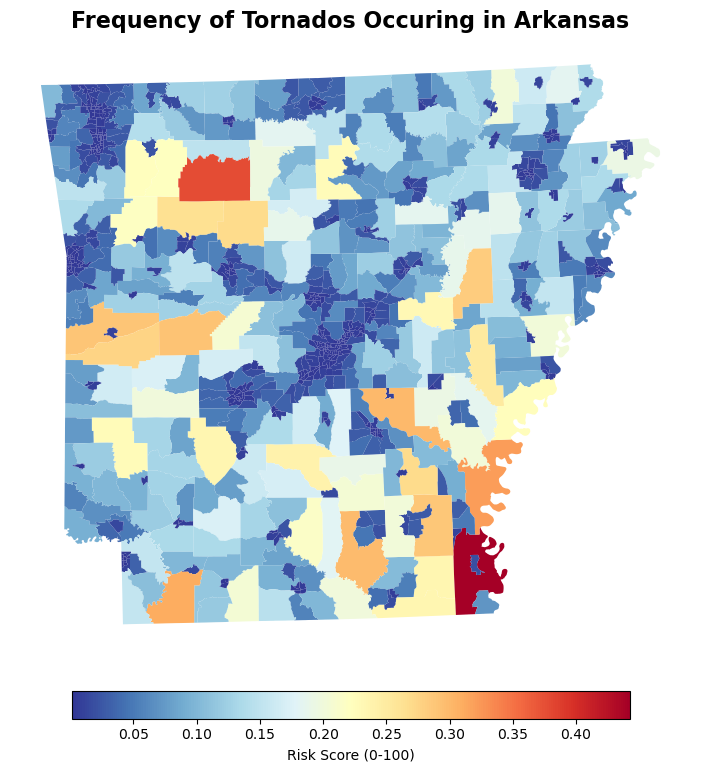

In [57]:
### Create Plot 1

## Frequency of Tornados occuring
fig,ax = plt.subplots(1,1, figsize = (12,10))

state_map_ar.plot(
    column = "TRND_AFREQ",
    cmap = "RdYlBu_r",
    aspect = 1, 
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6, "pad":0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("Frequency of Tornados Occuring in Arkansas", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

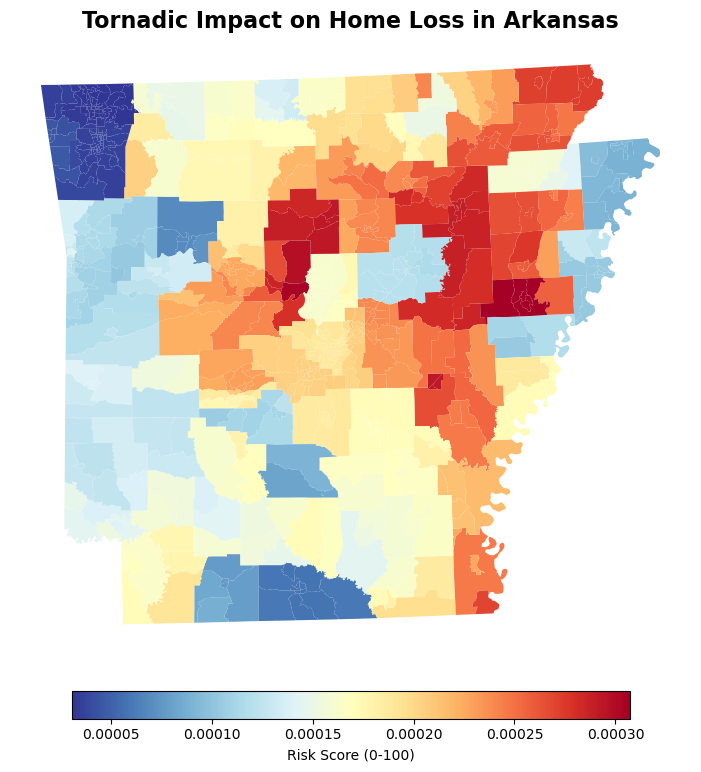

In [59]:
### Create Plot 2

## Tornadic Impact on Home Loss
fig,ax = plt.subplots(1,1, figsize = (12,10))

state_map_ar.plot(
    column = "TRND_ALRB",
    cmap = "RdYlBu_r",
    aspect = 1, 
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6, "pad":0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("Tornadic Impact on Home Loss in Arkansas", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

### Missouri Maps

In [62]:
# Filter for Missouri in SHP file
ms = "Missouri"
state_map_ms = tracts_clean[tracts_clean["STATE"] == ms]

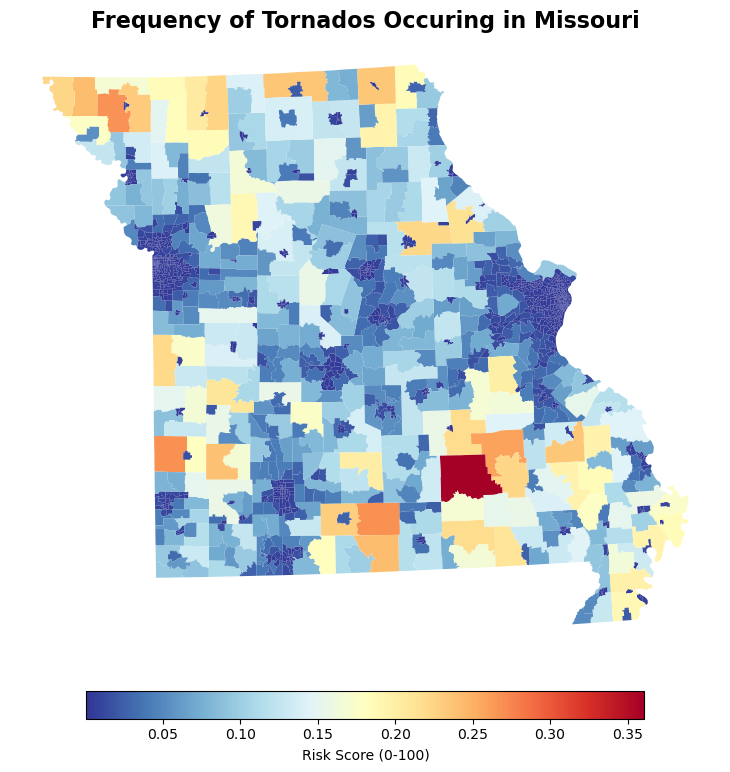

In [64]:
### Create Plot 1

## Frequency of Tornados occuring
fig,ax = plt.subplots(1,1, figsize = (12,10))

state_map_ms.plot(
    column = "TRND_AFREQ",
    cmap = "RdYlBu_r",
    aspect = 1, 
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6, "pad":0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("Frequency of Tornados Occuring in Missouri", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

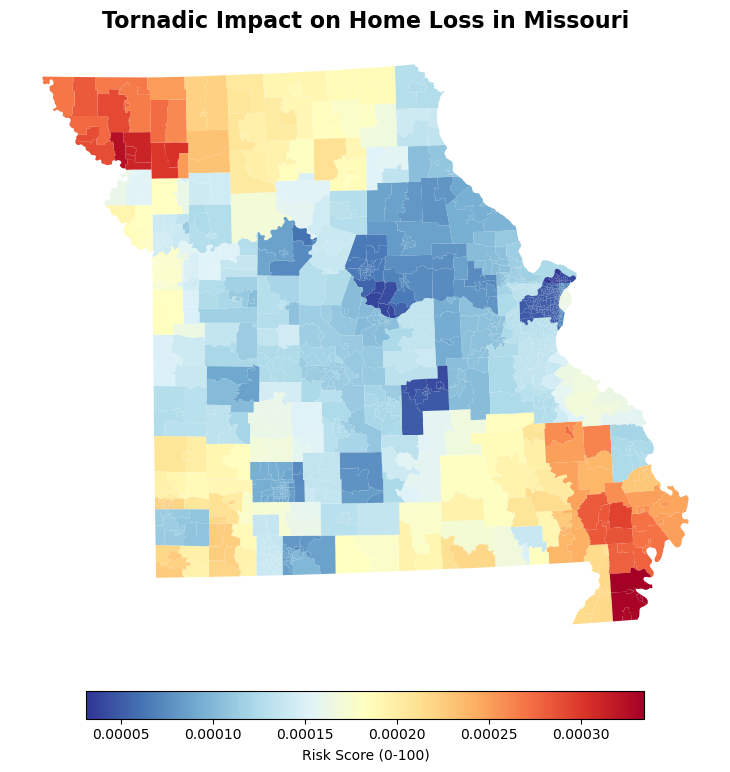

In [66]:
### Create Plot 2

## Tornadic Impact on Home Loss
fig,ax = plt.subplots(1,1, figsize = (12,10))

state_map_ms.plot(
    column = "TRND_ALRB",
    cmap = "RdYlBu_r",
    aspect = 1, 
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink":0.6, "pad":0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("Tornadic Impact on Home Loss in Missouri", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()